In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [69]:
DATASET_PATH = "/content/drive/My Drive/Colab Notebooks/dataset4kelas"

In [70]:
import os
import numpy as np
import pandas as pd

In [71]:
from sklearn.model_selection import train_test_split

EVENT_SIZE = 2000

label_map = {
    "diam":0,
    "jalan":1,
    "aktivitas":2,
    "jatuh":3
}

events = []
labels = []
event_names = []

for cls in label_map:

    folder = os.path.join(
        DATASET_PATH,
        cls
    )

    files = os.listdir(folder)

    print("\nCLASS :", cls)

    for file in files:

        fp = os.path.join(
            folder,
            file
        )

        try:

            df = pd.read_csv(fp)

            needed = [
                "ax","ay","az",
                "gx","gy","gz"
            ]

            if not all(
                col in df.columns
                for col in needed
            ):
                continue

            if len(df) < EVENT_SIZE:
                continue

            data = df[
                needed
            ].values

            data = data[:EVENT_SIZE]

            events.append(data)

            labels.append(
                label_map[cls]
            )

            event_names.append(file)

        except Exception as e:

            print(
                "ERROR:",
                file
            )

            print(e)

events = np.array(events)
labels = np.array(labels)

print(events.shape)
print(labels.shape)


CLASS : diam

CLASS : jalan

CLASS : aktivitas

CLASS : jatuh
(240, 2000, 6)
(240,)


In [72]:
path = "/content/drive/My Drive/Colab Notebooks/dataset4kelas/"

classes = [
    "diam",
    "jalan",
    "aktivitas",
    "jatuh"
]

all_peak = []

for cls in classes:

    folder = os.path.join(path, cls)

    files = os.listdir(folder)

    for file in files:

        try:

            fp = os.path.join(
                folder,
                file
            )

            df = pd.read_csv(fp)

            acc_mag = np.sqrt(
                df["ax"]**2 +
                df["ay"]**2 +
                df["az"]**2
            )

            peak = acc_mag.max()

            all_peak.append([
                cls,
                file,
                peak
            ])

        except Exception as e:

            print(file)
            print(e)

peak_df = pd.DataFrame(
    all_peak,
    columns=[
        "class",
        "file",
        "peak_acc"
    ]
)

peak_df.head()

,class,file,peak_acc
0,diam,duduk_tangan_dipaha_20260603_202519.csv,1.169497
1,diam,duduk_tangan_dipaha_20260603_202536.csv,1.032184
2,diam,duduk_tangan_dimeja_20260603_202609.csv,1.143091
3,diam,duduk_tangan_dimeja_20260603_202628.csv,1.248005
4,diam,duduk_tangan_dikursi_20260603_202702.csv,1.027576


In [73]:
for cls in classes:

    data = peak_df[
        peak_df["class"] == cls
    ]["peak_acc"]

    print("\n", cls)

    print("Jumlah :", len(data))

    print("Min    :", data.min())

    print("Q1     :", data.quantile(0.25))

    print("Median :", data.median())

    print("Q3     :", data.quantile(0.75))

    print("Max    :", data.max())

    print("Mean   :", data.mean())

    print("Std    :", data.std())


 diam
Jumlah : 60
Min    : 1.0091488145957463
Q1     : 1.0414739154927013
Median : 1.0546489745759482
Q3     : 1.1092129501415908
Max    : 1.3352595927384308
Mean   : 1.083300583493301
Std    : 0.0669530987098749

 jalan
Jumlah : 60
Min    : 1.2223889151984322
Q1     : 1.4762533931433202
Median : 1.660447387747733
Q3     : 1.9031632253858748
Max    : 2.344659474209421
Mean   : 1.6815779237621666
Std    : 0.25771853024093183

 aktivitas
Jumlah : 60
Min    : 1.0933211696477847
Q1     : 1.3073725164671588
Median : 1.6154635974248999
Q3     : 2.0768413707887663
Max    : 3.4639861460461994
Mean   : 1.728404686295139
Std    : 0.5285683877883306

 jatuh
Jumlah : 60
Min    : 2.630078930374524
Q1     : 3.4639861460461994
Median : 3.4640438810731022
Q3     : 3.4641016151377544
Max    : 3.4641016151377544
Mean   : 3.4254475716856114
Std    : 0.14381453852562281


In [74]:
bins = [
    0,
    1.5,
    2,
    2.5,
    3,
    3.5,
    4,
    5,
    10
]

for cls in classes:

    print("\n", cls)

    data = peak_df[
        peak_df["class"] == cls
    ]["peak_acc"]

    hist = pd.cut(
        data,
        bins=bins
    ).value_counts().sort_index()

    print(hist)


 diam
peak_acc
(0.0, 1.5]     60
(1.5, 2.0]      0
(2.0, 2.5]      0
(2.5, 3.0]      0
(3.0, 3.5]      0
(3.5, 4.0]      0
(4.0, 5.0]      0
(5.0, 10.0]     0
Name: count, dtype: int64

 jalan
peak_acc
(0.0, 1.5]     17
(1.5, 2.0]     37
(2.0, 2.5]      6
(2.5, 3.0]      0
(3.0, 3.5]      0
(3.5, 4.0]      0
(4.0, 5.0]      0
(5.0, 10.0]     0
Name: count, dtype: int64

 aktivitas
peak_acc
(0.0, 1.5]     24
(1.5, 2.0]     20
(2.0, 2.5]     11
(2.5, 3.0]      4
(3.0, 3.5]      1
(3.5, 4.0]      0
(4.0, 5.0]      0
(5.0, 10.0]     0
Name: count, dtype: int64

 jatuh
peak_acc
(0.0, 1.5]      0
(1.5, 2.0]      0
(2.0, 2.5]      0
(2.5, 3.0]      3
(3.0, 3.5]     57
(3.5, 4.0]      0
(4.0, 5.0]      0
(5.0, 10.0]     0
Name: count, dtype: int64


In [75]:
for cls in classes:

    print("\n==============")
    print(cls.upper())
    print("==============")

    temp = peak_df[
        peak_df["class"] == cls
    ]

    print("\nTERENDAH")

    print(
        temp.sort_values(
            "peak_acc"
        ).head(5)
    )

    print("\nTERTINGGI")

    print(
        temp.sort_values(
            "peak_acc",
            ascending=False
        ).head(5)
    )


DIAM

TERENDAH
   class                                               file  peak_acc
57  diam  berdiri_satu_tangan_menyilang_20260603_211654.csv  1.009149
53  diam          berdiri_melihat_bawah_20260603_211506.csv  1.013139
58  diam  berdiri_satu_tangan_menyilang_20260603_211713.csv  1.013949
13  diam            duduk_memegang_buku_20260603_203054.csv  1.022089
56  diam           berdiri_melihat_atas_20260603_211618.csv  1.025136

TERTINGGI
   class                                           file  peak_acc
59  diam  diam_duduk_tangandikepala_20260531_015025.csv  1.335260
8   diam    duduk_tangan_dipinggang_20260603_202847.csv  1.272000
3   diam        duduk_tangan_dimeja_20260603_202628.csv  1.248005
22  diam      duduk_tidak_bersandar_20260603_204000.csv  1.223429
7   diam        duduk_tangan_didada_20260603_202822.csv  1.192683

JALAN

TERENDAH
    class                                              file  peak_acc
66  jalan         jalan_lambat_lihat_hp_20260603_213019.csv  1.222389


In [76]:
length_data = []

for cls in classes:

    folder = os.path.join(
        path,
        cls
    )

    for file in os.listdir(folder):

        try:

            df = pd.read_csv(
                os.path.join(
                    folder,
                    file
                )
            )

            length_data.append([
                cls,
                len(df)
            ])

        except:
            pass

length_df = pd.DataFrame(
    length_data,
    columns=[
        "class",
        "samples"
    ]
)

length_df.groupby(
    "class"
)["samples"].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
aktivitas,60.0,2525.816667,402.774593,2015.0,2375.25,2490.0,2608.25,5332.0
diam,60.0,2342.883333,91.242105,2185.0,2304.75,2325.0,2354.25,2721.0
jalan,60.0,2458.983333,142.457426,2232.0,2341.50,2436.0,2539.25,2964.0
jatuh,60.0,2627.783333,527.753862,2168.0,2398.25,2516.0,2639.75,5639.0


In [77]:
jatuh_low = peak_df[
    (peak_df["class"]=="jatuh") &
    (peak_df["peak_acc"] < 2.5)
]

print(jatuh_low[
    ["file","peak_acc"]
].sort_values("peak_acc"))

Empty DataFrame
Columns: [file, peak_acc]
Index: []


In [78]:
for cls in label_map:

    folder = os.path.join(DATASET_PATH, cls)

    total = 0
    valid = 0

    for file in os.listdir(folder):

        total += 1

        try:

            df = pd.read_csv(
                os.path.join(folder, file)
            )

            needed = [
                "ax","ay","az",
                "gx","gy","gz"
            ]

            if not all(
                c in df.columns
                for c in needed
            ):
                continue

            if len(df) < 2000:
                continue

            valid += 1

        except:
            pass

    print(
        cls,
        "folder =", total,
        "valid =", valid
    )

diam folder = 60 valid = 60
jalan folder = 60 valid = 60
aktivitas folder = 60 valid = 60
jatuh folder = 60 valid = 60


In [79]:
folder = os.path.join(
    DATASET_PATH,
    "jatuh"
)

for file in os.listdir(folder):

    try:

        fp = os.path.join(folder, file)

        df = pd.read_csv(fp)

        needed = [
            "ax","ay","az",
            "gx","gy","gz"
        ]

        if not all(col in df.columns for col in needed):

            print(
                "KOLOM TIDAK LENGKAP :",
                file
            )

            continue

        if len(df) < 2000:

            print(
                "KURANG DARI 2000 :",
                file,
                "->",
                len(df)
            )

            continue

    except Exception as e:

        print(
            "ERROR :",
            file
        )

        print(e)

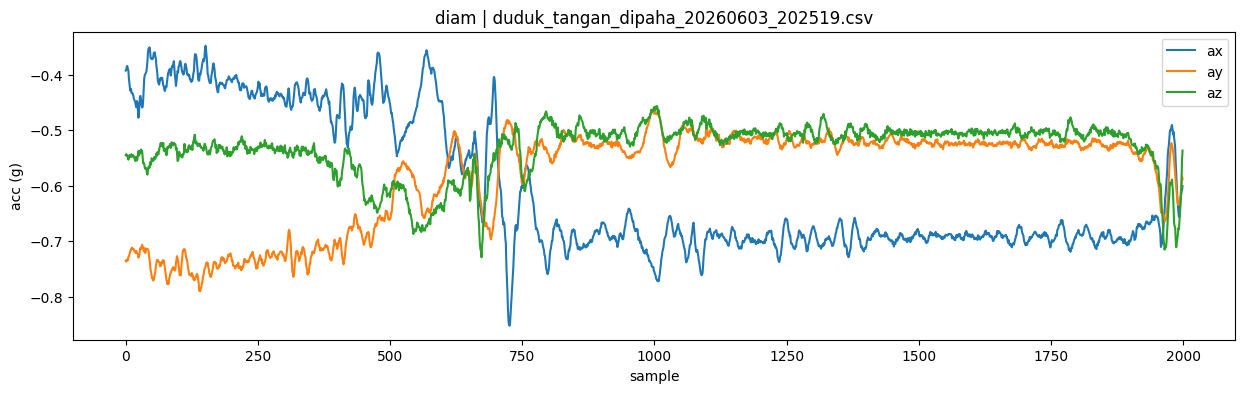

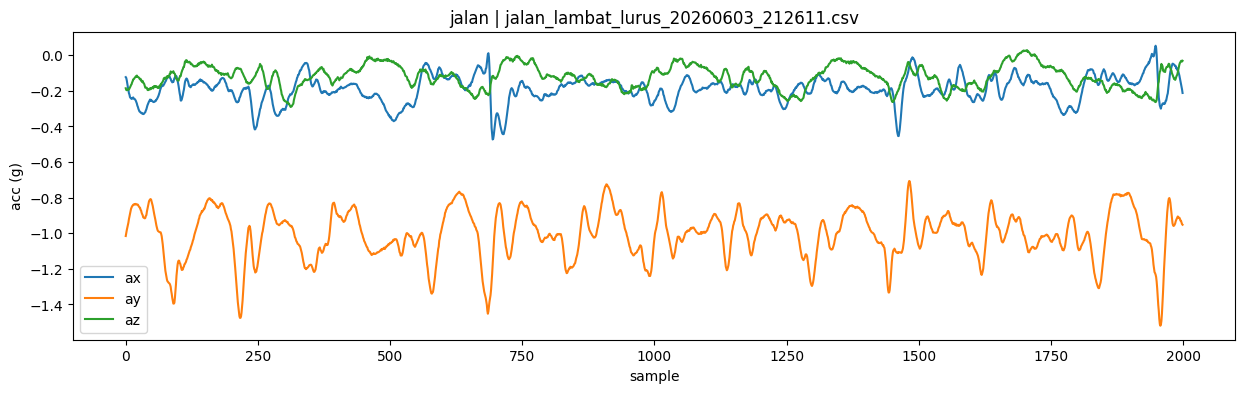

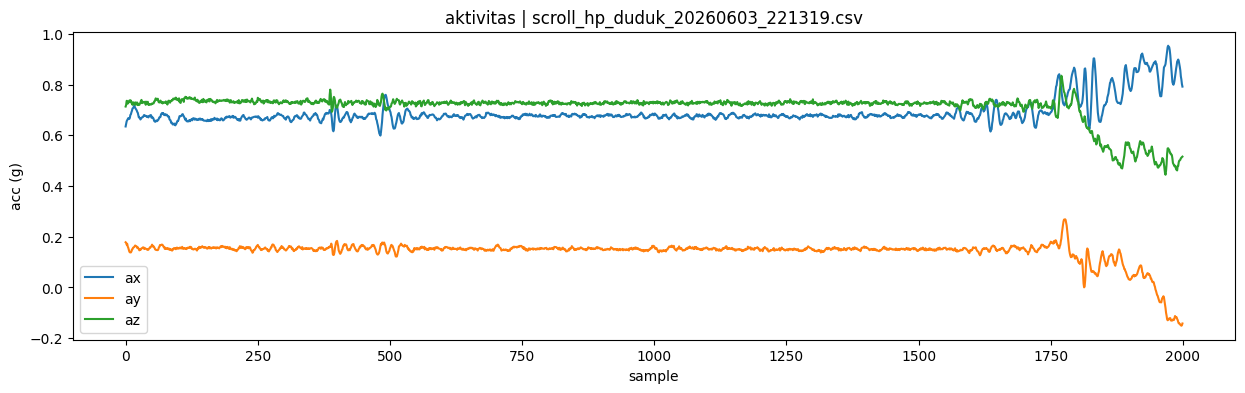

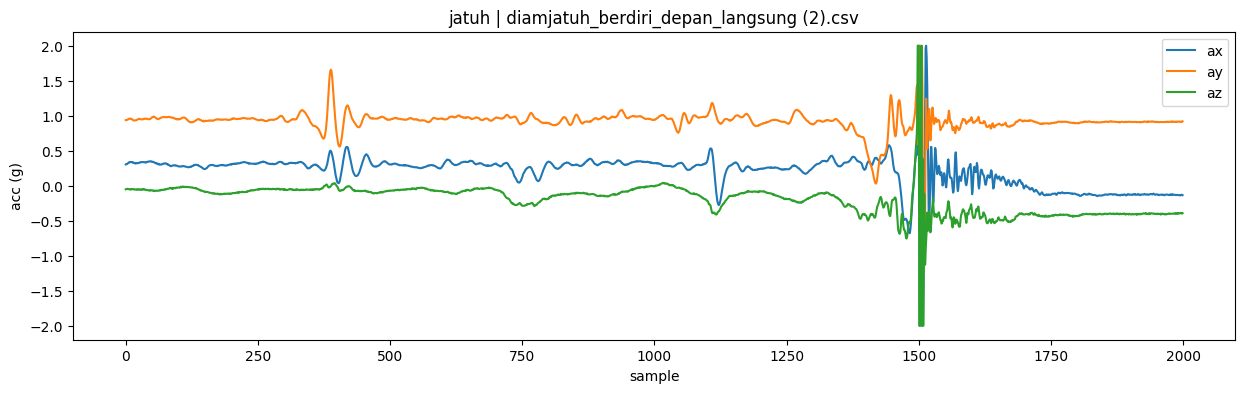

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# pilih event keberapa dari masing-masing kelas
SHOW_INDEX = 0

for cls_name, cls_id in label_map.items():

    idx = np.where(labels == cls_id)[0]

    event = events[idx[SHOW_INDEX]]

    plt.figure(figsize=(15,4))

    plt.plot(event[:,0], label='ax')
    plt.plot(event[:,1], label='ay')
    plt.plot(event[:,2], label='az')

    plt.title(f"{cls_name} | {event_names[idx[SHOW_INDEX]]}")
    plt.xlabel("sample")
    plt.ylabel("acc (g)")
    plt.legend()

    plt.show()

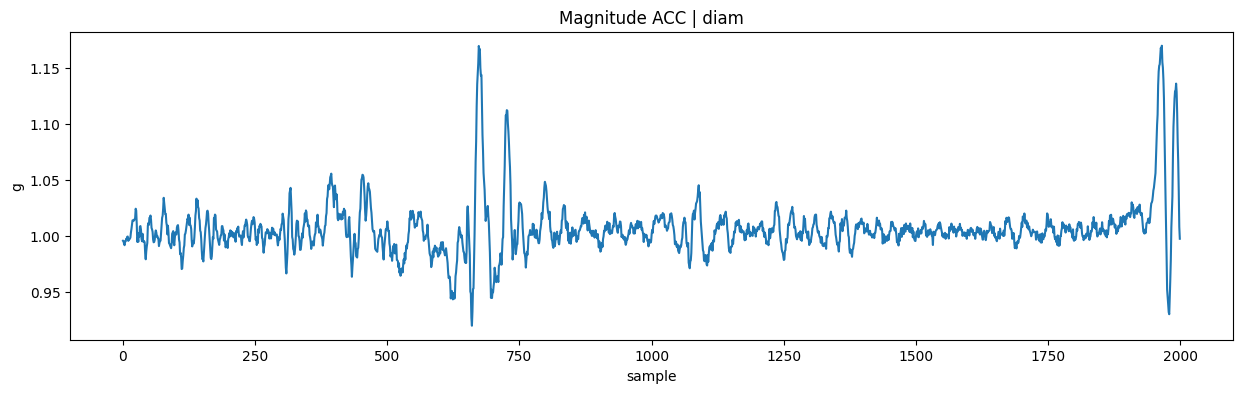

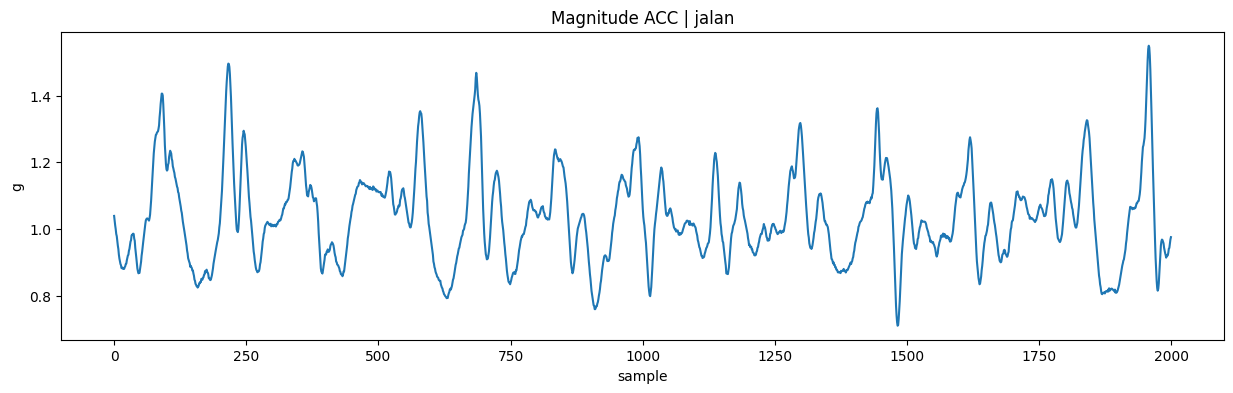

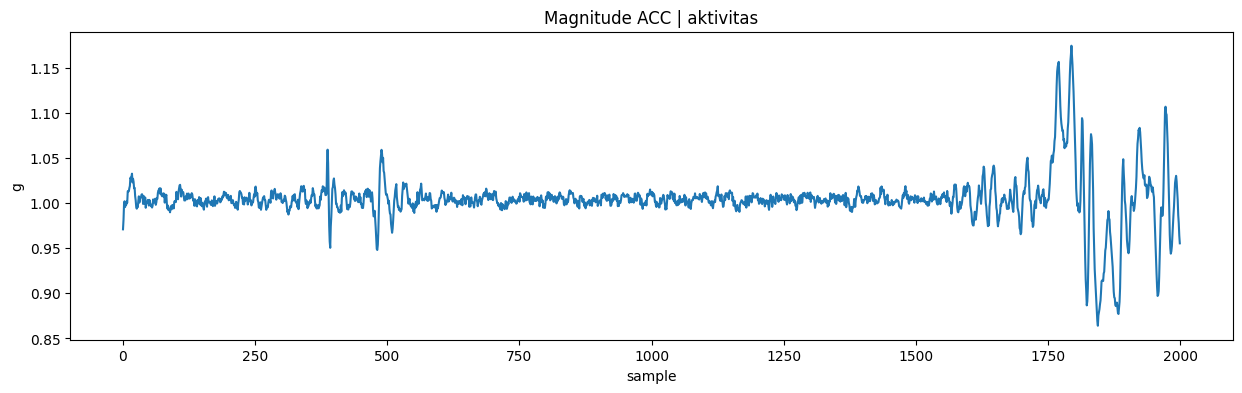

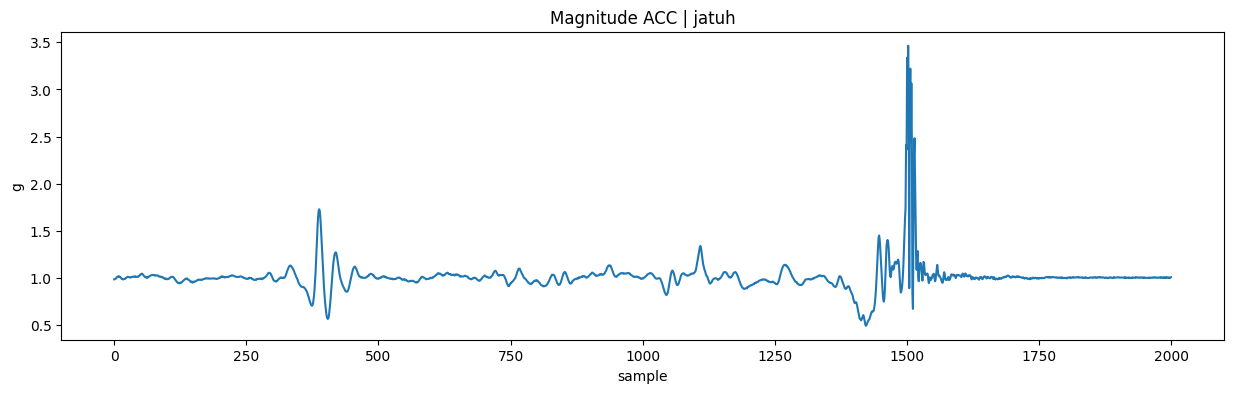

In [81]:
import matplotlib.pyplot as plt
import numpy as np

SHOW_INDEX = 0

for cls_name, cls_id in label_map.items():

    idx = np.where(labels == cls_id)[0]

    event = events[idx[SHOW_INDEX]]

    mag = np.sqrt(
        event[:,0]**2 +
        event[:,1]**2 +
        event[:,2]**2
    )

    plt.figure(figsize=(15,4))

    plt.plot(mag)

    plt.title(
        f"Magnitude ACC | {cls_name}"
    )

    plt.xlabel("sample")
    plt.ylabel("g")

    plt.show()

diam_duduk_tangandikepala_20260531_015025.csv


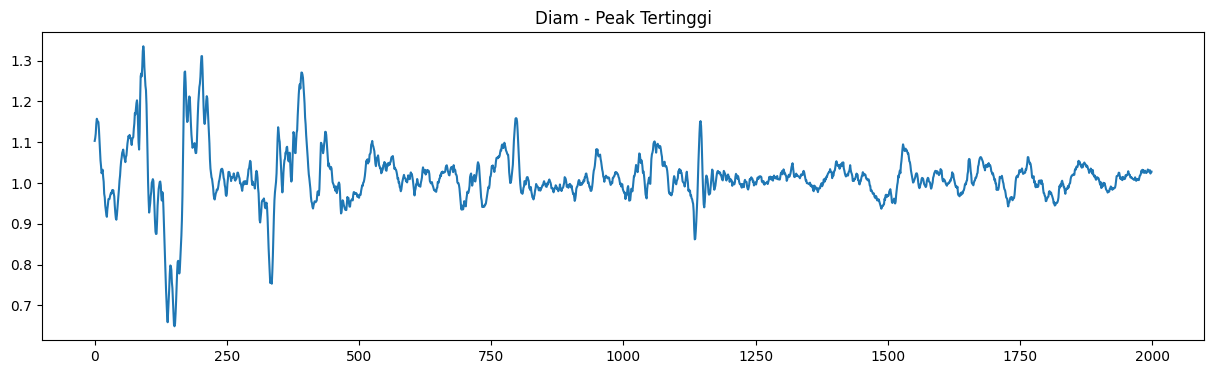

In [82]:
diam_idx = np.where(labels == 0)[0]

peak_list = []

for i in diam_idx:

    mag = np.sqrt(
        events[i,:,0]**2 +
        events[i,:,1]**2 +
        events[i,:,2]**2
    )

    peak_list.append(np.max(mag))

worst_idx = diam_idx[np.argmax(peak_list)]

print(event_names[worst_idx])

plt.figure(figsize=(15,4))
plt.plot(np.sqrt(
    events[worst_idx,:,0]**2 +
    events[worst_idx,:,1]**2 +
    events[worst_idx,:,2]**2
))
plt.title("Diam - Peak Tertinggi")
plt.show()

jalan_cepat_bolakbalik_20260603_220611.csv


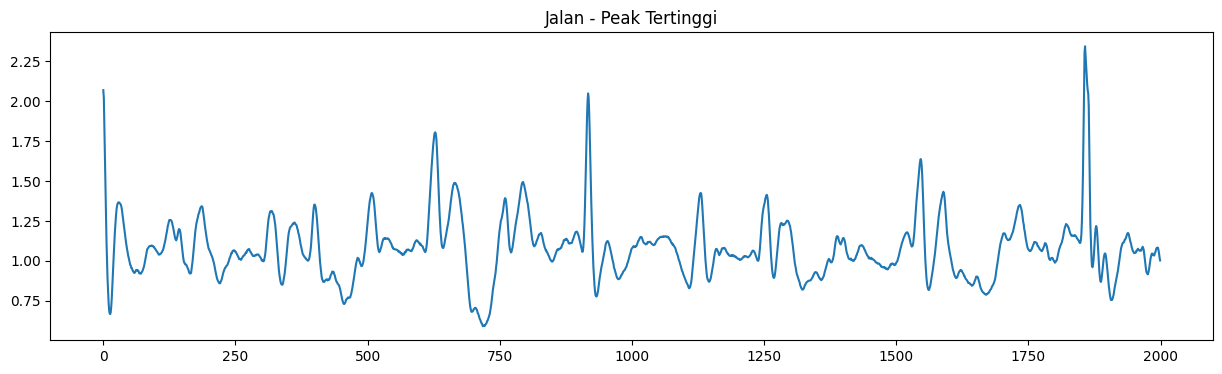

In [83]:
jalan_idx = np.where(labels == 1)[0]

peak_list = []

for i in jalan_idx:

    mag = np.sqrt(
        events[i,:,0]**2 +
        events[i,:,1]**2 +
        events[i,:,2]**2
    )

    peak_list.append(np.max(mag))

worst_idx = jalan_idx[np.argmax(peak_list)]

print(event_names[worst_idx])

plt.figure(figsize=(15,4))
plt.plot(np.sqrt(
    events[worst_idx,:,0]**2 +
    events[worst_idx,:,1]**2 +
    events[worst_idx,:,2]**2
))
plt.title("Jalan - Peak Tertinggi")
plt.show()

menunjuk_ke_depan_20260603_233351.csv


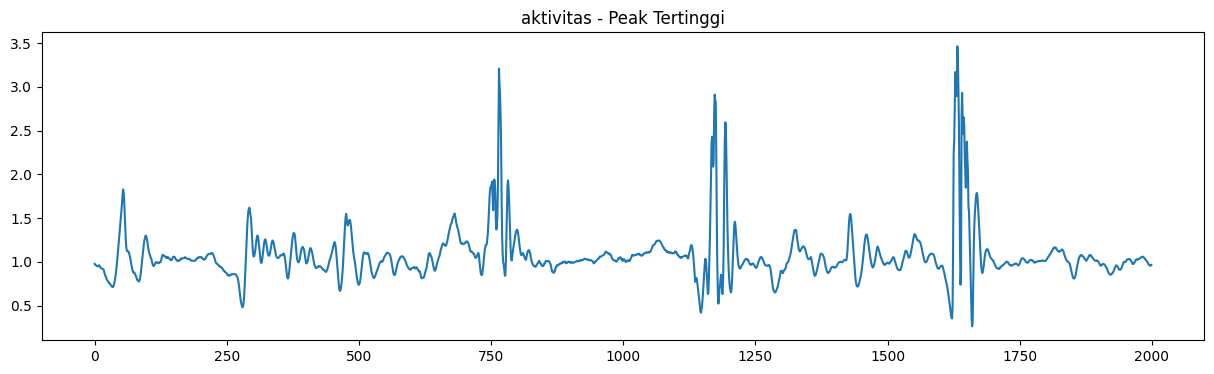

In [84]:
aktivitas_idx = np.where(labels == 2)[0]

peak_list = []

for i in aktivitas_idx:

    mag = np.sqrt(
        events[i,:,0]**2 +
        events[i,:,1]**2 +
        events[i,:,2]**2
    )

    peak_list.append(np.max(mag))

worst_idx = aktivitas_idx[np.argmax(peak_list)]

print(event_names[worst_idx])

plt.figure(figsize=(15,4))
plt.plot(np.sqrt(
    events[worst_idx,:,0]**2 +
    events[worst_idx,:,1]**2 +
    events[worst_idx,:,2]**2
))
plt.title("aktivitas - Peak Tertinggi")
plt.show()

menunjuk_ke_depan_20260603_233351.csv


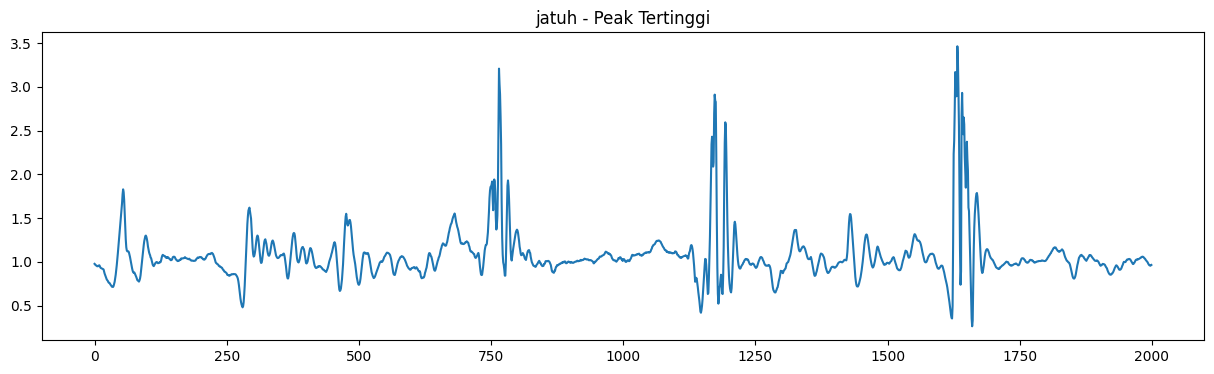

In [85]:
jatuh_idx = np.where(labels == 2)[0]

peak_list = []

for i in jatuh_idx:

    mag = np.sqrt(
        events[i,:,0]**2 +
        events[i,:,1]**2 +
        events[i,:,2]**2
    )

    peak_list.append(np.max(mag))

worst_idx = jatuh_idx[np.argmax(peak_list)]

print(event_names[worst_idx])

plt.figure(figsize=(15,4))
plt.plot(np.sqrt(
    events[worst_idx,:,0]**2 +
    events[worst_idx,:,1]**2 +
    events[worst_idx,:,2]**2
))
plt.title("jatuh - Peak Tertinggi")
plt.show()

In [86]:
from sklearn.model_selection import train_test_split

X_train_event, X_test_event, y_train_event, y_test_event = train_test_split(
    events,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(X_train_event.shape)
print(X_test_event.shape)

(192, 2000, 6)
(48, 2000, 6)


In [87]:
import pandas as pd

pd.Series(y_train_event).value_counts().sort_index()

,count
0,48
1,48
2,48
3,48


In [89]:
pd.Series(y_test_event).value_counts().sort_index()

,count
0,12
1,12
2,12
3,12


In [90]:
print("TRAIN")
print(pd.Series(y_train_event).value_counts().sort_index())

print("\nTEST")
print(pd.Series(y_test_event).value_counts().sort_index())

TRAIN
0    48
1    48
2    48
3    48
Name: count, dtype: int64

TEST
0    12
1    12
2    12
3    12
Name: count, dtype: int64


In [94]:
from sklearn.preprocessing import StandardScaler
import joblib
import os

scaler = StandardScaler()

train_2d = X_train_event.reshape(-1,6)

scaler.fit(train_2d)

# Define the directory path
scaler_dir = "/content/drive/My Drive/Colab Notebooks/model"

# Create the directory if it does not exist
os.makedirs(scaler_dir, exist_ok=True)

joblib.dump(
    scaler,
    os.path.join(scaler_dir, "scaler.pkl")
)

['/content/drive/My Drive/Colab Notebooks/model/scaler.pkl']

In [95]:
print("MEAN")
print(scaler.mean_)

print("\nSTD")
print(scaler.scale_)

MEAN
[ 0.19634467 -0.13807346 -0.17315581 -1.26857673  0.37358058 -0.31234502]

STD
[ 0.62535393  0.67403031  0.43203254 39.11692249 53.27510632 60.88830539]


In [96]:
X_train_event = scaler.transform(
    X_train_event.reshape(-1,6)
).reshape(X_train_event.shape)

X_test_event = scaler.transform(
    X_test_event.reshape(-1,6)
).reshape(X_test_event.shape)

In [97]:
def create_windows(events, labels,
                   window_size=400,
                   step=100):

    X = []
    y = []

    for event, label in zip(events, labels):

        for start in range(
            0,
            len(event)-window_size+1,
            step
        ):

            end = start + window_size

            X.append(event[start:end])
            y.append(label)

    return np.array(X), np.array(y)

In [98]:
WINDOW = 400
STEP = 100

X_train, y_train = create_windows(
    X_train_event,
    y_train_event,
    WINDOW,
    STEP
)

X_test, y_test = create_windows(
    X_test_event,
    y_test_event,
    WINDOW,
    STEP
)

print(X_train.shape)
print(X_test.shape)

(3264, 400, 6)
(816, 400, 6)


In [99]:
print(pd.Series(y_train).value_counts().sort_index())
print()
print(pd.Series(y_test).value_counts().sort_index())

0    816
1    816
2    816
3    816
Name: count, dtype: int64

0    204
1    204
2    204
3    204
Name: count, dtype: int64


In [100]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Conv1D(
        32,
        kernel_size=5,
        activation='relu',
        input_shape=(400,6)
    ),

    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(
        64,
        kernel_size=5,
        activation='relu'
    ),

    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(
        128,
        kernel_size=3,
        activation='relu'
    ),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        4,
        activation='softmax'
    )

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 396, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 198, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 194, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 97, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 95, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,516 (173.89 KB)

 Trainable params: 44,516 (173.89 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [104]:
#early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [105]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=50,
    batch_size=32,

    callbacks=[
        early_stop
    ],

    verbose=1
)

Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.6327 - loss: 0.8665 - val_accuracy: 0.7574 - val_loss: 0.6693
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.8143 - loss: 0.4794 - val_accuracy: 0.7880 - val_loss: 0.5802
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.8640 - loss: 0.3552 - val_accuracy: 0.8076 - val_loss: 0.5895
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8771 - loss: 0.3127 - val_accuracy: 0.8125 - val_loss: 0.5584
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9035 - loss: 0.2596 - val_accuracy: 0.8615 - val_loss: 0.5128
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9194 - loss: 0.2107 - val_accuracy: 0.8517 - val_loss: 0.5667
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9176 - loss: 0.2120 - val_accuracy: 0.8456 - val_loss: 0.5250
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9292 - loss: 0.1839 - val_acc

In [106]:
SAVE_MODEL = "/content/drive/My Drive/Colab Notebooks/model/model_4kelas.keras"

model.save(SAVE_MODEL)

print("MODEL SAVED")

MODEL SAVED


In [112]:
model.save(
"/content/drive/My Drive/Colab Notebooks/model/model_4kelas.keras"
)

In [115]:
from google.colab import files

files.download(
"/content/drive/My Drive/Colab Notebooks/model/scaler.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [116]:
from google.colab import files

files.download(
"/content/drive/My Drive/Colab Notebooks/model/label_map.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

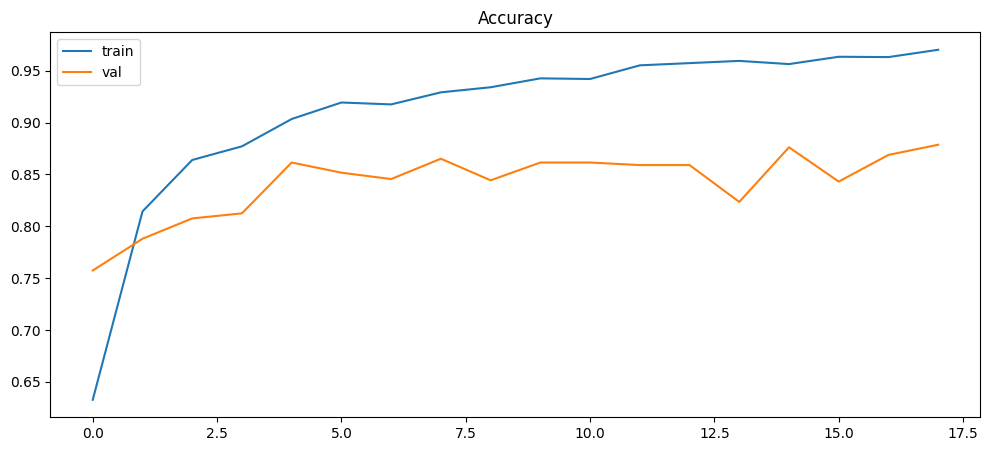

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='val'
)

plt.legend()
plt.title("Accuracy")

plt.show()

In [110]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [111]:
print("Train Acc :", history.history['accuracy'][-1])
print("Val Acc   :", history.history['val_accuracy'][-1])

print("Train Loss:", history.history['loss'][-1])
print("Val Loss  :", history.history['val_loss'][-1])

Train Acc : 0.9702818393707275
Val Acc   : 0.8786764740943909
Train Loss: 0.07992702722549438
Val Loss  : 0.6712276935577393


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


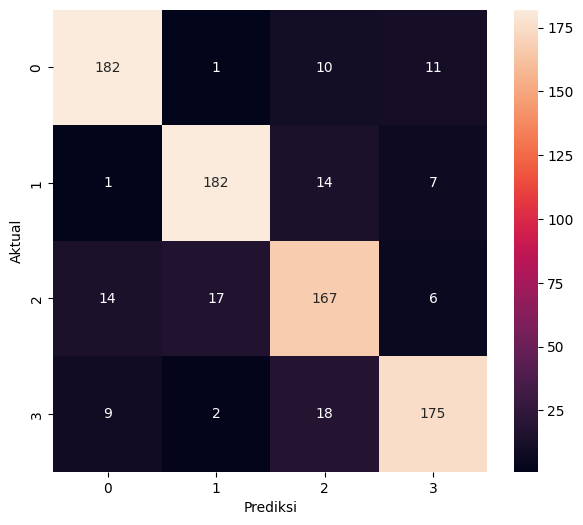

              precision    recall  f1-score   support

           0       0.88      0.89      0.89       204
           1       0.90      0.89      0.90       204
           2       0.80      0.82      0.81       204
           3       0.88      0.86      0.87       204

    accuracy                           0.87       816
   macro avg       0.87      0.87      0.87       816
weighted avg       0.87      0.87      0.87       816



In [108]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
import numpy as np

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

print(
    classification_report(
        y_test,
        y_pred
    )
)

In [119]:
print(cm)

[[182   1  10  11]
 [  1 182  14   7]
 [ 14  17 167   6]
 [  9   2  18 175]]


In [109]:
import json

label_map = {
    0:"diam",
    1:"jalan",
    2:"aktivitas",
    3:"jatuh"
}

with open(
    "/content/drive/My Drive/Colab Notebooks/model/label_map.json",
    "w"
) as f:

    json.dump(
        label_map,
        f,
        indent=4
    )

In [117]:
from sklearn.decomposition import PCA

X_flat = events.reshape(
    events.shape[0],
    -1
)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_flat)

In [118]:
print(
"PCA Variance:",
pca.explained_variance_ratio_
)

print(
"Total:",
sum(pca.explained_variance_ratio_)
)

PCA Variance: [0.06534242 0.06189412]
Total: 0.12723653627459616


In [120]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_flat)

cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

for i in [2,5,10,20,50,100]:
    print(i, cum_var[i-1])

2 0.12723653835788393
5 0.24896355956077132
10 0.37525095630970234
20 0.5444689554249252
50 0.8010419686988803
100 0.9555017826115296


In [121]:
import tensorflow as tf
import joblib
import numpy as np
import pandas as pd
import os
from collections import Counter

In [122]:
MODEL_PATH = "/content/drive/My Drive/Colab Notebooks/model/model_4kelas.keras"

SCALER_PATH = "/content/drive/My Drive/Colab Notebooks/model/scaler.pkl"

model = tf.keras.models.load_model(
    MODEL_PATH
)

scaler = joblib.load(
    SCALER_PATH
)

In [123]:
label_map = {
    0:"diam",
    1:"jalan",
    2:"aktivitas",
    3:"jatuh"
}

In [124]:
WINDOW = 400
STEP = 100

In [125]:
def predict_event(file_path):

    df = pd.read_csv(file_path)

    data = df[
        [
            "ax","ay","az",
            "gx","gy","gz"
        ]
    ].values

    data = scaler.transform(data)

    windows = []

    for start in range(
        0,
        len(data)-WINDOW+1,
        STEP
    ):

        end = start + WINDOW

        windows.append(
            data[start:end]
        )

    windows = np.array(windows)

    pred = model.predict(
        windows,
        verbose=0
    )

    pred = np.argmax(
        pred,
        axis=1
    )

    voting = Counter(pred)

    final_class = voting.most_common(1)[0][0]

    return (
        label_map[final_class],
        voting
    )

In [126]:
BASE_PATH = "/content/drive/My Drive/Colab Notebooks/eksternal_validation/"

In [127]:
for true_class in os.listdir(BASE_PATH):

    folder = os.path.join(
        BASE_PATH,
        true_class
    )

    if not os.path.isdir(folder):
        continue

    print("\n===================")
    print("TRUE :", true_class)
    print("===================")

    for file in os.listdir(folder):

        fp = os.path.join(
            folder,
            file
        )

        pred_class, voting = predict_event(fp)

        print("\nFILE :", file)

        print(
            "PRED :",
            pred_class
        )

        print(
            "WINDOW VOTING :",
            dict(voting)
        )


TRUE : diam

FILE : membungkuk_20260524_020823.csv
PRED : jatuh
WINDOW VOTING : {np.int64(2): 16, np.int64(3): 44}

TRUE : jalan

FILE : jalan_langkah_tidak_stabil_20260524_021437.csv
PRED : jatuh
WINDOW VOTING : {np.int64(3): 60, np.int64(2): 1}

TRUE : aktivitas

FILE : diam_duduk_tanganmenggarukbetis_20260531_015553.csv
PRED : jalan
WINDOW VOTING : {np.int64(1): 19, np.int64(3): 2}

TRUE : jatuh

FILE : jalanmundur_belakang_langsung.csv
PRED : jatuh
WINDOW VOTING : {np.int64(3): 13, np.int64(0): 6}


In [128]:
def create_windows(events, labels,
                   window_size,
                   step):

    X = []
    y = []

    for event, label in zip(events, labels):

        for start in range(
            0,
            len(event) - window_size + 1,
            step
        ):

            end = start + window_size

            X.append(event[start:end])
            y.append(label)

    return np.array(X), np.array(y)

In [129]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling1D,
    Dense
)

def build_model(window_size):

    model = Sequential([

        Conv1D(
            64,
            5,
            activation="relu",
            input_shape=(window_size, 6)
        ),

        BatchNormalization(),

        MaxPooling1D(2),

        Conv1D(
            128,
            5,
            activation="relu"
        ),

        BatchNormalization(),

        MaxPooling1D(2),

        GlobalAveragePooling1D(),

        Dense(
            128,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            4,
            activation="softmax"
        )

    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [130]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score
)

def run_experiment(
    window_size,
    step
):

    print("="*50)
    print(
        f"WINDOW={window_size} STEP={step}"
    )
    print("="*50)

    X_train, y_train = create_windows(
        X_train_event,
        y_train_event,
        window_size,
        step
    )

    X_test, y_test = create_windows(
        X_test_event,
        y_test_event,
        window_size,
        step
    )

    print(
        "TRAIN:",
        X_train.shape
    )

    print(
        "TEST :",
        X_test.shape
    )

    model = build_model(
        window_size
    )

    history = model.fit(

        X_train,
        y_train,

        validation_data=(
            X_test,
            y_test
        ),

        epochs=50,

        batch_size=32,

        callbacks=[
            early_stop
        ],

        verbose=1
    )

    y_pred = np.argmax(
        model.predict(X_test),
        axis=1
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    print()
    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    print(
        f"ACC = {acc:.4f}"
    )

    print(
        f"F1  = {f1:.4f}"
    )

    return model, history, acc, f1

In [131]:
model_A1, hist_A1, acc_A1, f1_A1 = run_experiment(
    400,
    100
)

WINDOW=400 STEP=100
TRAIN: (3264, 400, 6)
TEST : (816, 400, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 20s 155ms/step - accuracy: 0.7488 - loss: 0.6075 - val_accuracy: 0.6507 - val_loss: 0.8463
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.8545 - loss: 0.3945 - val_accuracy: 0.7635 - val_loss: 0.6208
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.8741 - loss: 0.3324 - val_accuracy: 0.8554 - val_loss: 0.4843
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.8869 - loss: 0.2965 - val_accuracy: 0.8407 - val_loss: 0.4627
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 168ms/step - accuracy: 0.8919 - loss: 0.2756 - val_accuracy: 0.8211 - val_loss: 0.5284
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.9154 - loss: 0.2278 - val_accuracy: 0.8493 - val_loss: 0.4568
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9206 - loss: 0.2073 - val_accuracy: 0.8775 - val_loss: 0.4521
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.9194 - loss: 0.2047 

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       204
           1       0.90      0.96      0.93       204
           2       0.82      0.89      0.85       204
           3       0.94      0.79      0.86       204

    accuracy                           0.88       816
   macro avg       0.88      0.88      0.88       816
weighted avg       0.88      0.88      0.88       816

ACC = 0.8775
F1  = 0.8769


In [132]:
model_A2, hist_A2, acc_A2, f1_A2 = run_experiment(
    400,
    50
)

WINDOW=400 STEP=50
TRAIN: (6336, 400, 6)
TEST : (1584, 400, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 35s 156ms/step - accuracy: 0.7885 - loss: 0.5299 - val_accuracy: 0.8188 - val_loss: 0.5668
Epoch 2/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.8769 - loss: 0.3256 - val_accuracy: 0.8782 - val_loss: 0.3831
Epoch 3/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 45s 160ms/step - accuracy: 0.9025 - loss: 0.2520 - val_accuracy: 0.8731 - val_loss: 0.4390
Epoch 4/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 41s 161ms/step - accuracy: 0.9149 - loss: 0.2197 - val_accuracy: 0.8687 - val_loss: 0.4709
Epoch 5/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 33s 167ms/step - accuracy: 0.9211 - loss: 0.2000 - val_accuracy: 0.8510 - val_loss: 0.5044
Epoch 6/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.9331 - loss: 0.1815 - val_accuracy: 0.8359 - val_loss: 0.5648
Epoch 7/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - accuracy: 0.9451 - loss: 0.1434 - val_accuracy: 0.8788 - val_loss: 0.4222
Epoch 8/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 26s 129ms/step - accuracy: 0.9430 - loss: 0.

In [133]:
model_A3, hist_A3, acc_A3, f1_A3 = run_experiment(
    400,
    200
)

WINDOW=400 STEP=200
TRAIN: (1728, 400, 6)
TEST : (432, 400, 6)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.6962 - loss: 0.7679 - val_accuracy: 0.7245 - val_loss: 1.0027
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.8079 - loss: 0.5024 - val_accuracy: 0.8148 - val_loss: 0.8137
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.8443 - loss: 0.4147 - val_accuracy: 0.8194 - val_loss: 0.6539
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.8507 - loss: 0.3860 - val_accuracy: 0.7917 - val_loss: 0.5594
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.8669 - loss: 0.3556 - val_accuracy: 0.8356 - val_loss: 0.4836
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8692 - loss: 0.3358 - val_accuracy: 0.8472 - val_loss: 0.4530
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.8634 - loss: 0.3235 - val_accuracy: 0.8241 - val_loss: 0.4613
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.8924 - loss: 0.2874 - val_accuracy: 0.8634 - val_loss

In [134]:
model_A4, hist_A4, acc_A4, f1_A4 = run_experiment(
    400,
    300
)

WINDOW=400 STEP=300
TRAIN: (1152, 400, 6)
TEST : (288, 400, 6)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.6693 - loss: 0.7973 - val_accuracy: 0.5799 - val_loss: 1.0710
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.8012 - loss: 0.5428 - val_accuracy: 0.7743 - val_loss: 0.8493
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.8212 - loss: 0.4639 - val_accuracy: 0.7812 - val_loss: 0.7573
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.8628 - loss: 0.3768 - val_accuracy: 0.7674 - val_loss: 0.6491
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.8576 - loss: 0.3636 - val_accuracy: 0.7465 - val_loss: 0.6047
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.8429 - loss: 0.3911 - val_accuracy: 0.8125 - val_loss: 0.5382
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.8776 - loss: 0.3281 - val_accuracy: 0.8368 - val_loss: 0.4707
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.8845 - loss: 0.3066 - val_accuracy: 0.8264 - val_loss: 0

In [135]:
model_A5, hist_A5, acc_A5, f1_A5 = run_experiment(
    400,
    80
)

WINDOW=400 STEP=80
TRAIN: (4032, 400, 6)
TEST : (1008, 400, 6)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.7500 - loss: 0.6217 - val_accuracy: 0.7708 - val_loss: 0.7123
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.8519 - loss: 0.3843 - val_accuracy: 0.8105 - val_loss: 0.4963
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8785 - loss: 0.3171 - val_accuracy: 0.8423 - val_loss: 0.4378
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.8931 - loss: 0.2785 - val_accuracy: 0.8631 - val_loss: 0.4269
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.9127 - loss: 0.2506 - val_accuracy: 0.8472 - val_loss: 0.4346
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.9085 - loss: 0.2313 - val_accuracy: 0.8581 - val_loss: 0.4744
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.9249 - loss: 0.1909 - val_accuracy: 0.8631 - val_loss: 0.4940
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.9204 - loss: 0.2005 - val_accuracy

In [138]:
model_B1, hist_B1, acc_B1, f1_B1 = run_experiment(
    200,
    199
)

WINDOW=200 STEP=199
TRAIN: (1920, 200, 6)
TEST : (480, 200, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.6703 - loss: 0.8050 - val_accuracy: 0.6417 - val_loss: 0.9996
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7630 - loss: 0.5778 - val_accuracy: 0.7146 - val_loss: 0.7834
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7990 - loss: 0.5068 - val_accuracy: 0.8042 - val_loss: 0.6374
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.8229 - loss: 0.4542 - val_accuracy: 0.7688 - val_loss: 0.5849
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.8479 - loss: 0.4225 - val_accuracy: 0.8354 - val_loss: 0.4893
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8521 - loss: 0.4041 - val_accuracy: 0.8562 - val_loss: 0.4809
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8542 - loss: 0.3835 - val_accuracy: 0.8521 - val_loss: 0.4610
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.8516 - loss: 0.3685 - val_accuracy: 0.7646 -

In [147]:
model_B2, hist_B2, acc_B2, f1_B2 = run_experiment(
    200,
    100
)

WINDOW=200 STEP=100
TRAIN: (3648, 200, 6)
TEST : (912, 200, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.7138 - loss: 0.7047 - val_accuracy: 0.8048 - val_loss: 0.8668
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8081 - loss: 0.4809 - val_accuracy: 0.7906 - val_loss: 0.6243
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.8427 - loss: 0.4159 - val_accuracy: 0.8191 - val_loss: 0.5327
Epoch 4/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8588 - loss: 0.3609 - val_accuracy: 0.8114 - val_loss: 0.5381
Epoch 5/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8649 - loss: 0.3467 - val_accuracy: 0.7895 - val_loss: 0.5488
Epoch 6/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.8676 - loss: 0.3212 - val_accuracy: 0.8147 - val_loss: 0.5222
Epoch 7/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.8972 - loss: 0.2914 - val_accuracy: 0.7993 - val_loss: 0.5567
Epoch 8/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8925 - loss: 0.2697 - val_acc

In [140]:
model_B3, hist_B3, acc_B3, f1_B3 = run_experiment(
    300,
    150
)

WINDOW=300 STEP=150
TRAIN: (2304, 300, 6)
TEST : (576, 300, 6)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.7079 - loss: 0.7188 - val_accuracy: 0.6562 - val_loss: 0.9678
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.7990 - loss: 0.4954 - val_accuracy: 0.7118 - val_loss: 0.7409
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.8377 - loss: 0.4370 - val_accuracy: 0.7812 - val_loss: 0.5675
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.8485 - loss: 0.3830 - val_accuracy: 0.8299 - val_loss: 0.4593
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.8698 - loss: 0.3329 - val_accuracy: 0.8594 - val_loss: 0.4680
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.8780 - loss: 0.3149 - val_accuracy: 0.7969 - val_loss: 0.5507
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.8655 - loss: 0.3321 - val_accuracy: 0.8021 - val_loss: 0.5315
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.8898 - loss: 0.2833 - val_accuracy: 0.8559 - val_loss: 

In [141]:
model_B4, hist_B4, acc_B4, f1_B4 = run_experiment(
    500,
    250
)

WINDOW=500 STEP=250
TRAIN: (1344, 500, 6)
TEST : (336, 500, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.6615 - loss: 0.8108 - val_accuracy: 0.6280 - val_loss: 1.0153
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.7939 - loss: 0.5085 - val_accuracy: 0.7619 - val_loss: 0.8493
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.8132 - loss: 0.4536 - val_accuracy: 0.7946 - val_loss: 0.6838
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.8579 - loss: 0.3842 - val_accuracy: 0.7798 - val_loss: 0.6413
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.8661 - loss: 0.3527 - val_accuracy: 0.7827 - val_loss: 0.5040
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.8720 - loss: 0.3277 - val_accuracy: 0.7679 - val_loss: 0.5306
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.8705 - loss: 0.3274 - val_accuracy: 0.8512 - val_loss: 0.4271
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.8728 - loss: 0.3019 - val_accuracy: 0.8

In [142]:
model_B5, hist_B5, acc_B5, f1_B5 = run_experiment(
    500,
    100
)

WINDOW=500 STEP=100
TRAIN: (3072, 500, 6)
TEST : (768, 500, 6)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - accuracy: 0.7484 - loss: 0.6383 - val_accuracy: 0.8086 - val_loss: 0.7866
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.8512 - loss: 0.3791 - val_accuracy: 0.7656 - val_loss: 0.6082
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.8812 - loss: 0.3117 - val_accuracy: 0.8542 - val_loss: 0.4085
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.8952 - loss: 0.2703 - val_accuracy: 0.8542 - val_loss: 0.4573
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 158ms/step - accuracy: 0.9167 - loss: 0.2273 - val_accuracy: 0.8555 - val_loss: 0.4042
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.9124 - loss: 0.2254 - val_accuracy: 0.8307 - val_loss: 0.4615
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.9329 - loss: 0.1766 - val_accuracy: 0.8906 - val_loss: 0.4252
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.9303 - loss: 0.1837 - val_accuracy: 0.8424 

In [143]:
model_B6, hist_B6, acc_B6, f1_B6 = run_experiment(
    300,
    100
)

WINDOW=300 STEP=100
TRAIN: (3456, 300, 6)
TEST : (864, 300, 6)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.7234 - loss: 0.6715 - val_accuracy: 0.7350 - val_loss: 0.8337
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.8264 - loss: 0.4405 - val_accuracy: 0.8160 - val_loss: 0.5420
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.8573 - loss: 0.3584 - val_accuracy: 0.8322 - val_loss: 0.5019
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.8631 - loss: 0.3414 - val_accuracy: 0.8368 - val_loss: 0.4364
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.8796 - loss: 0.2974 - val_accuracy: 0.8264 - val_loss: 0.4472
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.8955 - loss: 0.2602 - val_accuracy: 0.8403 - val_loss: 0.4672
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.9022 - loss: 0.2449 - val_accuracy: 0.8715 - val_loss: 0.4150
Epoch 8/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.9045 - loss: 0.2375 - val_accuracy: 0.

In [148]:
results = pd.DataFrame({

    "Experiment":[
        "A1",
        "A2",
        "A3",
        "A4",
        "A5",
        "B1",
        "B2",
        "B3",
        "B4",
        "B5",
        "B6"
    ],

    "Window":[
        400,
        400,
        400,
        400,
        400,
        200,
        200,
        300,
        500,
        500,
        300

    ],

    "Step":[
        100,
        50,
        200,
        300,
        80,
        199,
        100,
        150,
        250,
        100,
        100
    ],

    "Accuracy":[
        acc_A1,
        acc_A2,
        acc_A3,
        acc_A4,
        acc_A5,
        acc_B1,
        acc_B2,
        acc_B3,
        acc_B4,
        acc_B5,
        acc_B6
    ],

    "F1":[
        f1_A1,
        f1_A2,
        f1_A3,
        f1_A4,
        f1_A5,
        f1_B1,
        f1_B2,
        f1_B3,
        f1_B4,
        f1_B5,
        f1_B6
    ]

})

results

,Experiment,Window,Step,Accuracy,F1
0,A1,400,100,0.877451,0.876942
1,A2,400,50,0.878157,0.876753
2,A3,400,200,0.724537,0.720984
3,A4,400,300,0.737939,0.743111
4,A5,400,80,0.770833,0.767222
5,B1,200,199,0.641667,0.620238
6,B2,200,100,0.804825,0.802108
7,B3,300,150,0.656250,0.630789
8,B4,500,250,0.627976,0.584284
9,B5,500,100,0.808594,0.812051
